<img src="https://upload.wikimedia.org/wikipedia/commons/3/35/Uba_fiuba_ingenieria_logo.png" width="300" align="center">



# **Analisis de Series de Tiempo II**

# **Clase 5, Ejercicio, N-BEATS vs N-HiTS**

In [ ]:
!pip install neuralforecast statsmodels

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 308.0/308.0 kB 7.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 348.6/348.6 kB 19.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 831.6/831.6 kB 34.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 74.2/74.2 MB 12.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.6/46.6 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 19.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 265.7/265.7 kB 13.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.5/87.5 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 44.2 MB/s eta 0:00:00


Instalamos lo necesario

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm

from neuralforecast import NeuralForecast
from neuralforecast.models import NBEATS, NHITS
from neuralforecast.losses.pytorch import MAE

Definimos los parámetros

In [ ]:
horizonte = 12  # 12 meses a predecir
ventana_entrada = 24 # 24 meses de contexto
max_epochs = 150

Importamos los datos

In [ ]:
co2_raw = sm.datasets.co2.load_pandas().data
co2_raw.index = pd.to_datetime(co2_raw.index)
serie = co2_raw["co2"].resample("MS").mean().interpolate().dropna()

Formato 'long' requerido por neuralforecast: ['unique_id', 'ds', 'y']

In [ ]:
df = pd.DataFrame({
    "unique_id": "CO2",
    "ds": serie.index,
    "y": serie.values,
})

In [ ]:
print(f"Observaciones: {len(df)}  |  "
      f"desde {df['ds'].min().date()} hasta {df['ds'].max().date()}")

Observaciones: 526  |  desde 1958-03-01 hasta 2001-12-01


In [ ]:
train = df.iloc[:-horizonte].reset_index(drop=True)
test = df.iloc[-horizonte:].reset_index(drop=True)

Definimos los modelos

In [ ]:
modelos = [
    NBEATS(
        h=horizonte,
        input_size=ventana_entrada,
        max_steps=max_epochs,
        loss=MAE(),
        random_seed=42,
    ),
    NHITS(
        h=horizonte,
        input_size=ventana_entrada,
        max_steps=max_epochs,
        loss=MAE(),
        random_seed=42,
    )
]

INFO:lightning_fabric.utilities.seed:Seed set to 42
INFO:lightning_fabric.utilities.seed:Seed set to 42


In [ ]:
nf = NeuralForecast(models=modelos, freq="MS")
nf.fit(df=train)
forecast = nf.predict()

print("\nColumnas devueltas por predict():")
print(list(forecast.columns))

INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.callbacks.model_summary:
  | Name                | Type          | Params | Mode 
--------------------------------------------------------------
0 | loss                | MAE           | 0      | train
1 | hist_cat_embeddings | ModuleList    | 0      | train
2 | futr_cat_embeddings | ModuleList    | 0      | train
3 | stat_cat_embeddings | ModuleList    | 0      | train
4 | padder_train        | ConstantPad1d | 0      | train
5 | scaler              | TemporalNorm  | 0      | train
6 | blocks              | ModuleList    | 2.4 M  | train
--------------------------------------------------------------
2.4 M     Trainable params
900       Non-trainable params
2.4 M     Total params
9.789     Total estimated model params size (MB)
34        Modules in train mode
0         Modules in eval mode


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.


Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_steps=150` reached.
INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
/usr/local/lib/python3.12/dist-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.


Predicting: |          | 0/? [00:00<?, ?it/s]

INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores


Predicting: |          | 0/? [00:00<?, ?it/s]


Columnas devueltas por predict():
['unique_id', 'ds', 'NBEATS', 'NHITS']


In [ ]:
modelos_a_evaluar = ["NBEATS", "NHITS"]

Métricas

In [ ]:
def mae(y_real, y_pred):
    return float(np.mean(np.abs(y_real - y_pred)))

def rmse(y_real, y_pred):
    return float(np.sqrt(np.mean((y_real - y_pred) ** 2)))

def mape(y_real, y_pred):
    return float(np.mean(np.abs((y_real - y_pred) / y_real)) * 100)


Función para evaluar

In [ ]:
def evaluar_modelos(test, forecast, nombres_modelos):
    y_real = test["y"].values
    resultados = []
    for nombre in nombres_modelos:
        y_pred = forecast[nombre].values
        resultados.append({
            "modelo": nombre,
            "MAE": mae(y_real, y_pred),
            "RMSE": rmse(y_real, y_pred),
            "MAPE (%)": mape(y_real, y_pred),
        })
    return pd.DataFrame(resultados)

In [ ]:
tabla_resultados = evaluar_modelos(test, forecast, ["NBEATS", "NHITS"])
print(tabla_resultados)

   modelo       MAE      RMSE  MAPE (%)
0  NBEATS  1.105402  1.365978  0.297536
1   NHITS  1.261566  1.647419  0.339335


Visualización

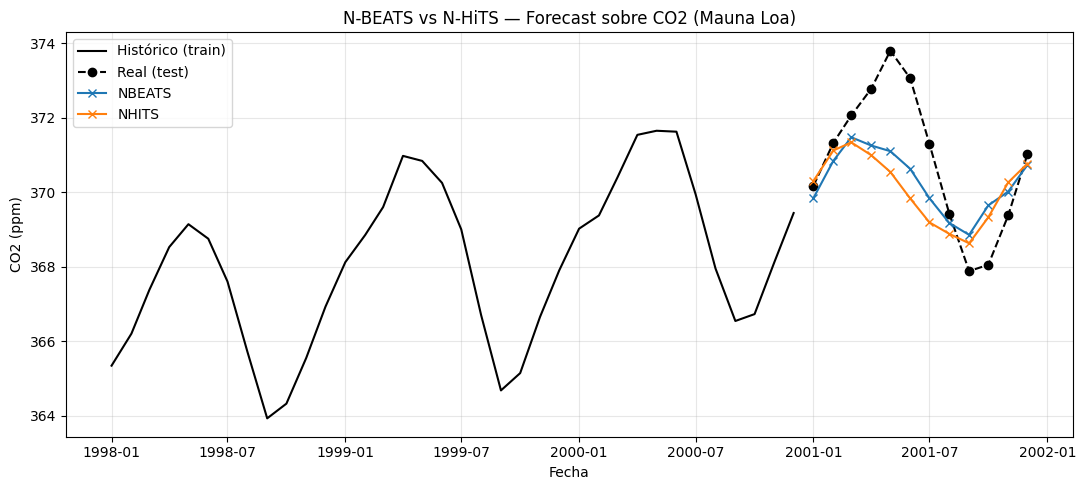

In [ ]:
def graficar_comparacion(train, test, forecast, nombres_modelos, ultimos_n=36):
    historico = train.tail(ultimos_n)

    plt.figure(figsize=(11, 5))
    plt.plot(historico["ds"], historico["y"], label="Histórico (train)", color="black")
    plt.plot(test["ds"], test["y"], label="Real (test)", color="black",
             linestyle="--", marker="o")

    colores = {"NBEATS": "tab:blue", "NHITS": "tab:orange"}
    for nombre in nombres_modelos:
        plt.plot(forecast["ds"], forecast[nombre], label=nombre,
                 color=colores.get(nombre), marker="x")

    plt.title("N-BEATS vs N-HiTS — Forecast sobre CO2 (Mauna Loa)")
    plt.xlabel("Fecha")
    plt.ylabel("CO2 (ppm)")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig("nbeats_vs_nhits_co2.png", dpi=150)
    plt.show()

graficar_comparacion(train, test, forecast, ["NBEATS", "NHITS"])